# Cancelation Prediction With CatBoost

## Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
from sklearn.base import BaseEstimator, TransformerMixin
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from pathlib import Path

import sys
import os
sys.path.append(os.path.abspath(".."))
from common_functions import optimal_f1_search

## Data Import

In [2]:
feature_path = "../../data/features/cancellation/v1/"

X_train = pd.read_parquet(feature_path + "X_train.parquet")
X_test  = pd.read_parquet(feature_path + "X_test.parquet")

y_train = pd.read_parquet(feature_path + "y_train.parquet")
y_test  = pd.read_parquet(feature_path + "y_test.parquet")

## Pipeline

In [3]:
categorical_features = [
    "hotel", "meal", "market_segment", "distribution_channel",
    "customer_type", "deposit_type", "arrival_date_month", "country", "agent"
]

numerical_features = [
    "lead_time", "arrival_date_year", "arrival_date_week_number",
    "arrival_date_day_of_month", "stays_in_weekend_nights", "stays_in_week_nights",
    "adults", "children", "babies", "previous_cancellations",
    "previous_bookings_not_canceled", "days_in_waiting_list",
    "adr", "required_car_parking_spaces", "total_of_special_requests",
    "is_repeated_guest"
]

required_features = categorical_features + numerical_features

# For CatBoost, we can include "arrival_season" as a categorical feature, since CatBoost can handle categorical features natively, and arrival_season is an engineered categorical feature.
cat_features = categorical_features + ["arrival_season"]

In [4]:
class SchemaValidator(BaseEstimator, TransformerMixin):
    def __init__(self, required_columns):
        self.required_columns = required_columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        missing = [c for c in self.required_columns if c not in X.columns]
        if missing:
            raise ValueError(
                f"Model input schema violation. Missing columns: {missing}"
            )
        return X

In [5]:
class FillCategoricalMissing(BaseEstimator, TransformerMixin):
    def __init__(self, categorical_columns):
        self.categorical_columns = categorical_columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.categorical_columns:
            X[col] = X[col].astype(str).fillna("missing")
        return X

In [6]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['total_stay'] = X['stays_in_weekend_nights'] + X['stays_in_week_nights']
        X['adr_per_person'] = X['adr'] / (X['adults'] + X['children'] + X['babies']).replace(0,1)
        # simple season mapping
        def week_to_season(week):
            if 10 <= week <= 21:
                return 'Spring'
            elif 22 <= week <= 34:
                return 'Summer'
            elif 35 <= week <= 47:
                return 'Fall'
            else:
                return 'Winter'
        X['arrival_season'] = X['arrival_date_week_number'].apply(week_to_season)
        return X

In [7]:
class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, selected_columns):
        self.selected_columns = selected_columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.selected_columns]

In [8]:
model = CatBoostClassifier(
    # Basic hyperparameters
    iterations=800,      # number of boosting rounds
    task_type='GPU',      # enable GPU
    devices='0',          # GPU device
    verbose=100,          # print progress every 100 iterations
    random_state=42,
    cat_features=cat_features
)

In [9]:
steps = [
    ('schema_validator', SchemaValidator(required_features)),
    ('fill_categorical_missing', FillCategoricalMissing(categorical_features)),
    ('feature_engineering', FeatureEngineer()),
    ('feature_selector', FeatureSelector(required_features + ['total_stay', 'adr_per_person', 'arrival_season'])),
    ('model', model)
]

In [10]:
pipeline = Pipeline(steps)

## First Search

### Parameters to search for

In [11]:
param_distributions_1 = {
    'model__depth': [4, 6, 8, 10],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'model__l2_leaf_reg': [1, 3, 5, 7, 9],
    'model__bagging_temperature': [0, 0.25, 0.5, 0.75, 1],
    'model__border_count': [32, 64, 128, 254],
    'model__min_data_in_leaf': [1, 5, 10, 20],
    # 'model__colsample_bylevel': [0.6, 0.8, 1.0], # Ok to explore when using CPU
    'model__colsample_bylevel': [1.0], # Set to 1.0 to avoid issues with GPU training; 1.0 by default, but setting explicitly here for clarity
    'model__random_strength': [1, 2, 5, 10]
}

### Randomized search setup

In [12]:
random_search_1 = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions_1,
    n_iter=50, # Number of random combinations to try
    cv=3,
    scoring="roc_auc",
    verbose=2,
    n_jobs=1, # Use 1 to avoid potential GPU conflicts
    random_state=42,
    # error_score='raise' # uncomment to raise errors during fitting
)

### Search

In [13]:
random_search_1.fit(X_train, y_train)

cat_boost_pipeline_1 = random_search_1.best_estimator_
random_search_1.best_params_

Fitting 3 folds for each of 50 candidates, totalling 150 fits
0:	learn: 0.5727173	total: 78.8ms	remaining: 1m 2s
100:	learn: 0.2360289	total: 6.7s	remaining: 46.4s
200:	learn: 0.1829932	total: 13.6s	remaining: 40.6s
300:	learn: 0.1469347	total: 20.5s	remaining: 33.9s
400:	learn: 0.1213740	total: 27.4s	remaining: 27.2s
500:	learn: 0.1019620	total: 34.5s	remaining: 20.6s
600:	learn: 0.0863368	total: 41.8s	remaining: 13.8s
700:	learn: 0.0738688	total: 49.1s	remaining: 6.94s
799:	learn: 0.0639976	total: 57s	remaining: 0us
[CV] END model__bagging_temperature=0.75, model__border_count=128, model__colsample_bylevel=1.0, model__depth=10, model__l2_leaf_reg=1, model__learning_rate=0.1, model__min_data_in_leaf=5, model__random_strength=5; total time=  58.1s
0:	learn: 0.5742768	total: 59.6ms	remaining: 47.6s
100:	learn: 0.2351000	total: 6.71s	remaining: 46.5s
200:	learn: 0.1867473	total: 13.4s	remaining: 40s
300:	learn: 0.1516254	total: 20.1s	remaining: 33.3s
400:	learn: 0.1236527	total: 26.9s	re

{'model__random_strength': 5,
 'model__min_data_in_leaf': 5,
 'model__learning_rate': 0.05,
 'model__l2_leaf_reg': 3,
 'model__depth': 10,
 'model__colsample_bylevel': 1.0,
 'model__border_count': 64,
 'model__bagging_temperature': 0.75}

### Evaluation

In [14]:
y_pred_train_1 = cat_boost_pipeline_1.predict(X_train)
y_pred_test_1 = cat_boost_pipeline_1.predict(X_test)

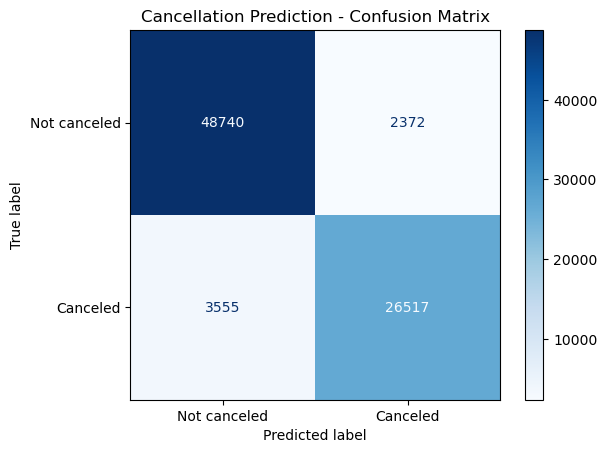

              precision    recall  f1-score   support

Not canceled       0.93      0.95      0.94     51112
    Canceled       0.92      0.88      0.90     30072

    accuracy                           0.93     81184
   macro avg       0.92      0.92      0.92     81184
weighted avg       0.93      0.93      0.93     81184



In [15]:
disp_train_1 = ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred_train_1,
    display_labels=["Not canceled", "Canceled"],
    cmap="Blues",
    normalize=None
)
disp_train_1.ax_.set_title("Cancellation Prediction - Confusion Matrix")
plt.show();

print(classification_report(y_train, y_pred_train_1, target_names=["Not canceled", "Canceled"]))

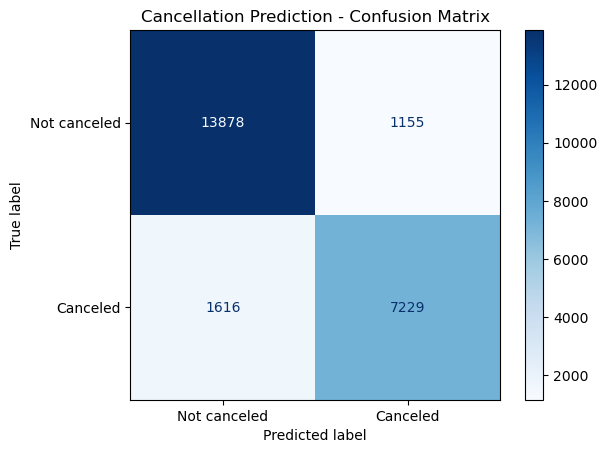

              precision    recall  f1-score   support

Not canceled       0.90      0.92      0.91     15033
    Canceled       0.86      0.82      0.84      8845

    accuracy                           0.88     23878
   macro avg       0.88      0.87      0.87     23878
weighted avg       0.88      0.88      0.88     23878



In [16]:
disp_test_1 = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test_1,
    display_labels=["Not canceled", "Canceled"],
    cmap="Blues",
    normalize=None
)
disp_test_1.ax_.set_title("Cancellation Prediction - Confusion Matrix")
plt.show();

print(classification_report(y_test, y_pred_test_1, target_names=["Not canceled", "Canceled"]))

ROC-AUC: 0.9556572976797945


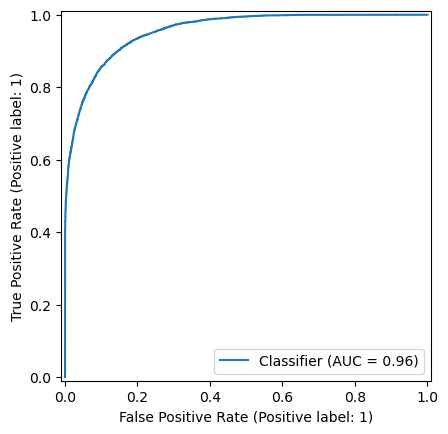

In [17]:
y_probs_1 = cat_boost_pipeline_1.predict_proba(X_test)[:,1]
auc_1 = roc_auc_score(y_test, y_probs_1)
print("ROC-AUC:", auc_1)

RocCurveDisplay.from_predictions(y_test, y_probs_1)
plt.show();

Best threshold: 0.43
Best F1: 0.844891122278057


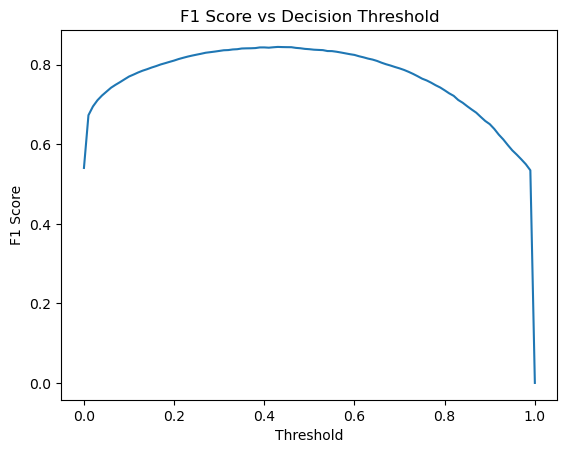

In [18]:
optimal_f1_search(y_test, y_probs_1)

## Second Model

### Parameters to search for

In [19]:
# Refined hyperparameter search based on initial results
param_distributions_2 = {
    'model__depth': [9, 10],
    'model__learning_rate': [0.04, 0.05, 0.06, 0.07],
    'model__l2_leaf_reg': [2, 3, 4],
    'model__bagging_temperature': [0.65, 0.75, 0.85],
    'model__border_count': [64],
    'model__min_data_in_leaf': [3, 4, 5, 6, 7],
    'model__colsample_bylevel': [1.0],
    'model__random_strength': [4, 5, 6, 7]
}

### Randomized search setup

In [20]:
random_search_2 = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions_2,
    n_iter=40, # Reduced number of iterations for refined search
    cv=3,
    scoring="roc_auc",
    verbose=2,
    n_jobs=1,
    random_state=42
)

### Search

In [21]:
random_search_2.fit(X_train, y_train)

cat_boost_pipeline_2 = random_search_2.best_estimator_
random_search_2.best_params_

Fitting 3 folds for each of 40 candidates, totalling 120 fits
0:	learn: 0.6470810	total: 39.3ms	remaining: 31.4s
100:	learn: 0.2904642	total: 4.73s	remaining: 32.8s
200:	learn: 0.2679104	total: 9.39s	remaining: 28s
300:	learn: 0.2526898	total: 13.9s	remaining: 23.1s
400:	learn: 0.2392187	total: 18.4s	remaining: 18.4s
500:	learn: 0.2267290	total: 23s	remaining: 13.7s
600:	learn: 0.2171185	total: 27.6s	remaining: 9.14s
700:	learn: 0.2076663	total: 32.2s	remaining: 4.55s
799:	learn: 0.1984655	total: 36.7s	remaining: 0us
[CV] END model__bagging_temperature=0.65, model__border_count=64, model__colsample_bylevel=1.0, model__depth=9, model__l2_leaf_reg=4, model__learning_rate=0.04, model__min_data_in_leaf=5, model__random_strength=4; total time=  37.4s
0:	learn: 0.6466986	total: 38.2ms	remaining: 30.5s
100:	learn: 0.2890250	total: 4.7s	remaining: 32.5s
200:	learn: 0.2679494	total: 9.3s	remaining: 27.7s
300:	learn: 0.2538408	total: 13.9s	remaining: 23s
400:	learn: 0.2399216	total: 20.4s	remain

{'model__random_strength': 4,
 'model__min_data_in_leaf': 7,
 'model__learning_rate': 0.05,
 'model__l2_leaf_reg': 2,
 'model__depth': 10,
 'model__colsample_bylevel': 1.0,
 'model__border_count': 64,
 'model__bagging_temperature': 0.75}

### Evaluation

In [22]:
y_pred_train_2 = cat_boost_pipeline_2.predict(X_train)
y_pred_test_2 = cat_boost_pipeline_2.predict(X_test)

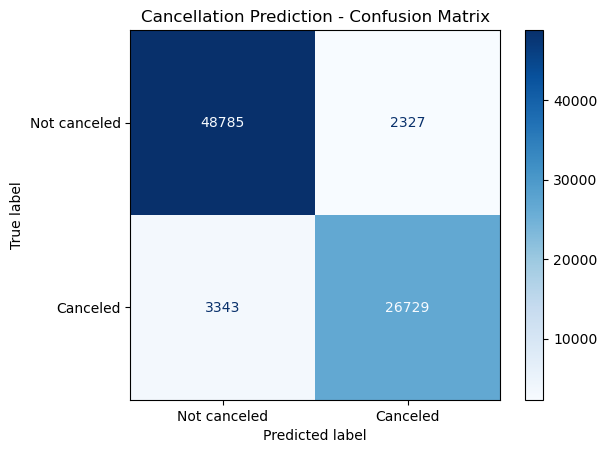

              precision    recall  f1-score   support

Not canceled       0.94      0.95      0.95     51112
    Canceled       0.92      0.89      0.90     30072

    accuracy                           0.93     81184
   macro avg       0.93      0.92      0.92     81184
weighted avg       0.93      0.93      0.93     81184



In [23]:
disp_train_2 = ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred_train_2,
    display_labels=["Not canceled", "Canceled"],
    cmap="Blues",
    normalize=None
)
disp_train_2.ax_.set_title("Cancellation Prediction - Confusion Matrix")
plt.show();

print(classification_report(y_train, y_pred_train_2, target_names=["Not canceled", "Canceled"]))

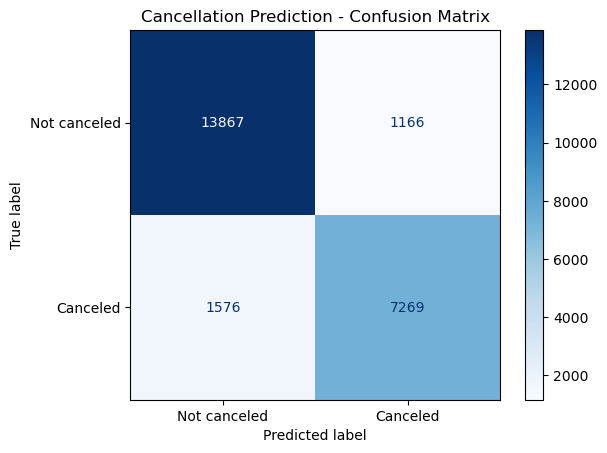

              precision    recall  f1-score   support

Not canceled       0.90      0.92      0.91     15033
    Canceled       0.86      0.82      0.84      8845

    accuracy                           0.89     23878
   macro avg       0.88      0.87      0.88     23878
weighted avg       0.88      0.89      0.88     23878



In [24]:
disp_test_2 = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test_2,
    display_labels=["Not canceled", "Canceled"],
    cmap="Blues",
    normalize=None
)
disp_test_2.ax_.set_title("Cancellation Prediction - Confusion Matrix")
plt.show();

print(classification_report(y_test, y_pred_test_2, target_names=["Not canceled", "Canceled"]))

ROC-AUC: 0.9555237832336976


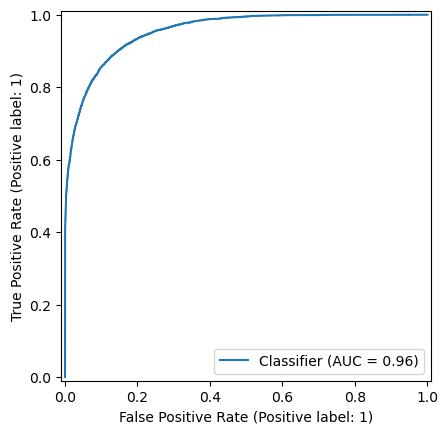

In [25]:
y_probs_2 = cat_boost_pipeline_2.predict_proba(X_test)[:,1]
auc_2 = roc_auc_score(y_test, y_probs_2)
print("ROC-AUC:", auc_2)

RocCurveDisplay.from_predictions(y_test, y_probs_2)
plt.show();

Best threshold: 0.44
Best F1: 0.84493777329297


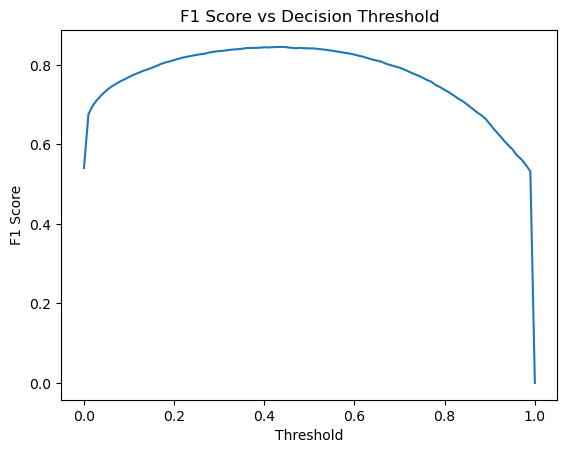

In [26]:
optimal_f1_search(y_test, y_probs_2)

## Config saving

### Best parameters

In [30]:
clean_params = {
    k.replace('model__', ''): v
    for k, v in random_search_2.best_params_.items()
}

clean_params

{'random_strength': 4,
 'min_data_in_leaf': 7,
 'learning_rate': 0.05,
 'l2_leaf_reg': 2,
 'depth': 10,
 'colsample_bylevel': 1.0,
 'border_count': 64,
 'bagging_temperature': 0.75}

### Training configurations

In [ ]:
training_config = {
    'name': 'cancellation',
    'task': 'binary_classification',
    'version': 'v1',

    'data': {
        "features_path": "data/features/cancellation/v1/",
        "features_version": "v1",
        "target": "is_canceled",
        "train_file": "X_train.parquet",
        "val_file": "X_val.parquet",
        "test_file": "X_test.parquet",
        "y_train": "y_train.parquet",
        "y_val": "y_val.parquet",
        "y_test": "y_test.parquet"
    },

    'model': {
        'class': "CatBoostClassifier",
        'algorithm': 'catboost',
        'params': {
            **clean_params,
            'iterations': 2500, # increase iterations for final training
            'task_type': 'CPU',    # switch to CPU for final model
            'random_state': 42,
            'verbose': 200
        },
        'threshold': 0.44
    },

    'pipeline': {
        'validate_schema': True,
        'fill_categorical_missing': True,
        'feature_engineering': True,
        'feature_selection': True
    },

    'explainability': {
        'feature_importance_method': 'PredictionValuesChange',
        'shap_method': 'tree_explainer_mean_abs'
    }
}

#### Save

In [33]:
config_path = Path("../../training/config/cancellation_v1.yaml")
config_path.parent.mkdir(parents=True, exist_ok=True)

with open(config_path, 'w') as file:
    yaml.safe_dump(training_config, file, sort_keys=False)

## END OF FILE